In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('semiconductor_yield_forecasting_data.csv')

In [3]:
#The objective of this analysis is to compare process parameter distributions between low-yield and normal-yield wafers. 
#This helps validate whether the parameters identified in the correlation analysis show meaningful distribution differences in lower-yield wafers.

In [4]:
df['yield'].describe()

count    1250.000000
mean        0.456679
std         0.175306
min         0.148086
25%         0.323588
50%         0.415796
75%         0.573955
max         0.982489
Name: yield, dtype: float64

In [5]:
#define low-yield threshold as bottom 25% of yield
low_yield_threshold = df['yield'].quantile(0.25)
low_yield_threshold

np.float64(0.3235880559128249)

In [6]:
#create group
df['yield_group']= np.where(df['yield']<= low_yield_threshold, 'Low Yield', 'Normal Yield')
df['yield_group'].value_counts()

yield_group
Normal Yield    937
Low Yield       313
Name: count, dtype: int64

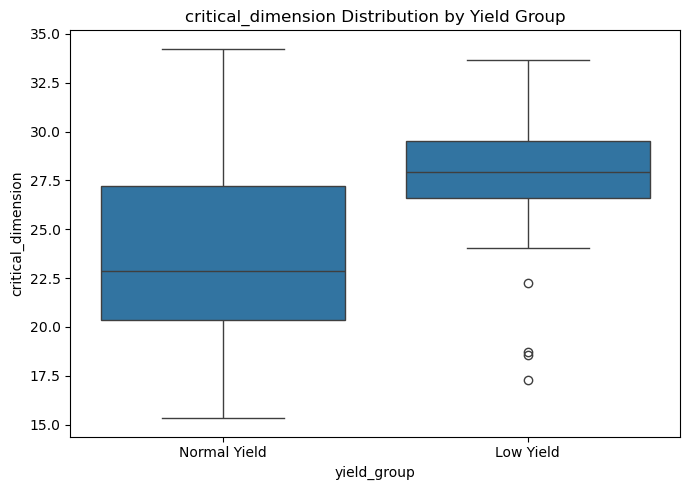

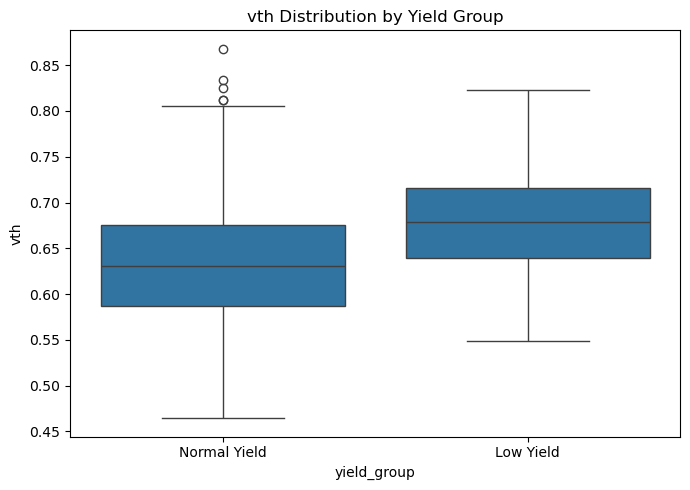

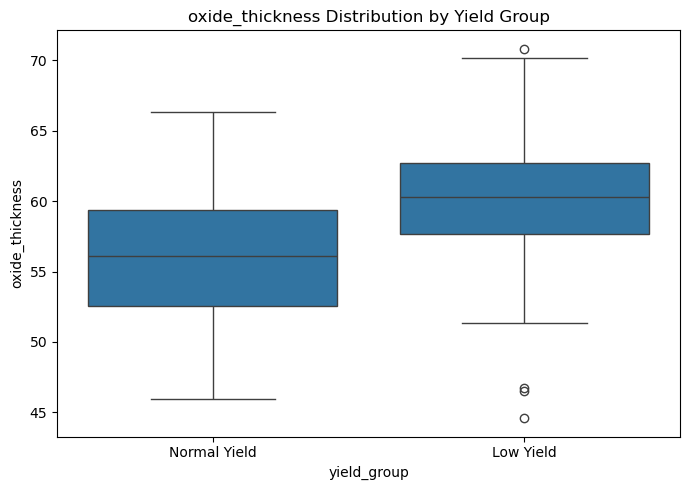

In [7]:
#boxplot- choose first 3 key parameters (high correlation with yield)
key_params = ['critical_dimension','vth','oxide_thickness']

for param in key_params:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x='yield_group', y=param)
    plt.title(f'{param} Distribution by Yield Group')
    plt.tight_layout()
    plt.show()

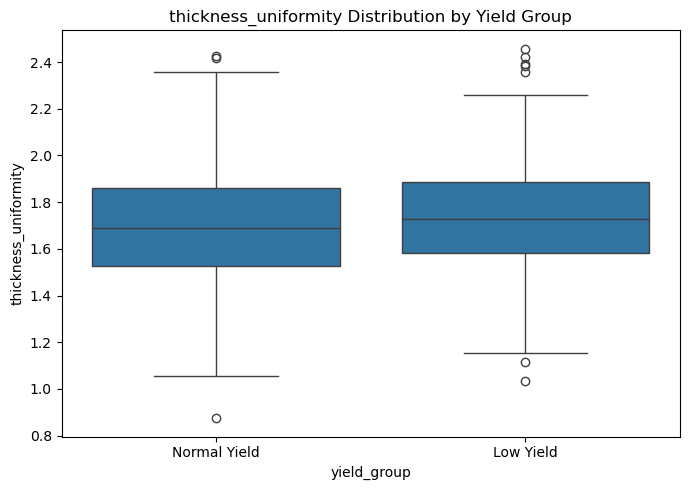

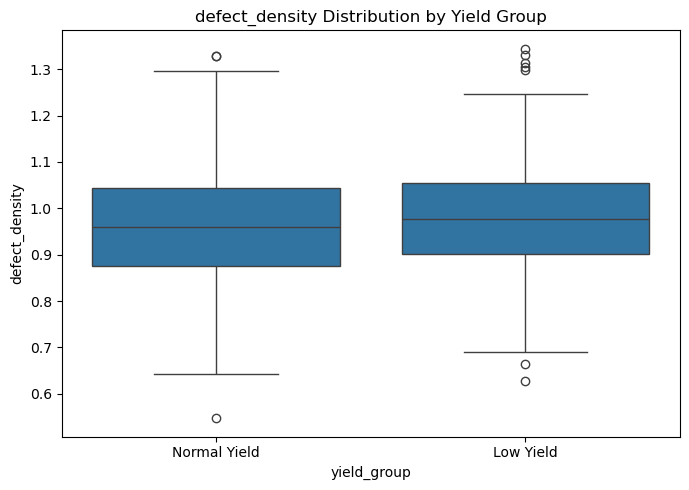

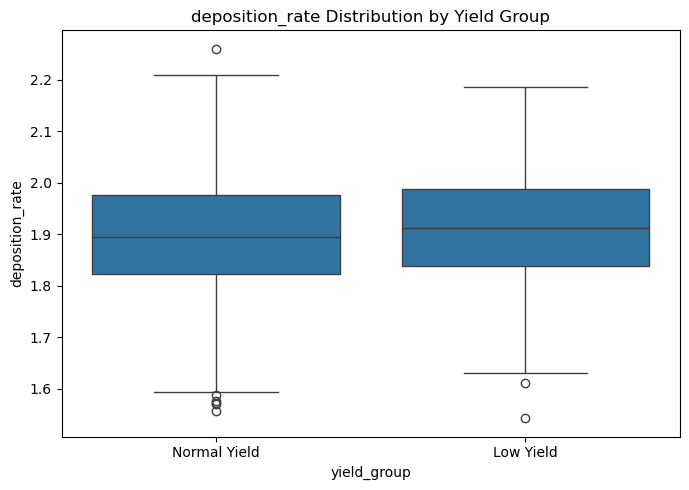

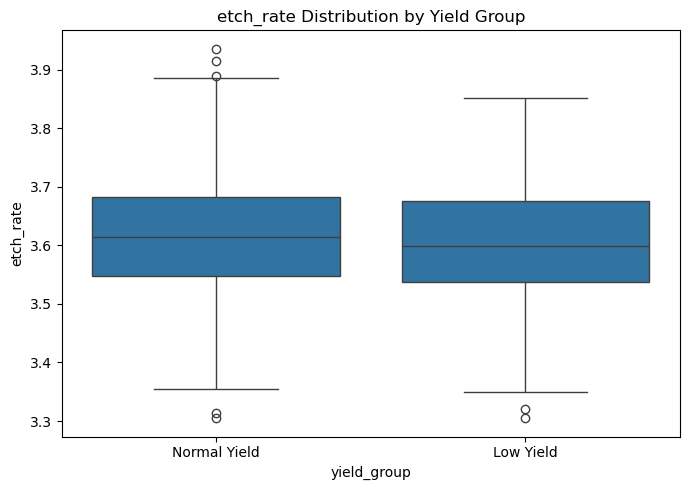

In [8]:
#check remaining parameter boxplot
key_params = ['thickness_uniformity','defect_density','deposition_rate','etch_rate']

for param in key_params:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x='yield_group', y=param)
    plt.title(f'{param} Distribution by Yield Group')
    plt.tight_layout()
    plt.show()

### Key Findings

Low-yield wafers showed noticeable differences in critical dimension, Vth, and oxide thickness compared with normal-yield wafers.This supports the correlation analysis, where these three parameters had the strongest negative relationship with yield.

The other parameters showed less obvious separation between yield groups, suggesting that their overall impact on yield may be weaker, process-specific, or non-linear.